# 00b — Statistiques descriptives par segment

On reprend la base obtenue à la fin du notebook 00 (périmètre final, dossiers joints unifiés, segment SA / SB) et on décrit les variables séparément dans chaque segment, puisque chaque segment aura son propre modèle.

Pour chaque segment :
1. valeurs manquantes ;
2. variables constantes ou presque ;
3. distributions et valeurs extrêmes ;
4. variables qualitatives ;
5. redondances entre variables ;
6. pouvoir discriminant (IV) ;
7. synthèse : statut provisoire de chaque variable avant la discrétisation, et export Excel.

In [2]:
import polars as pl
from utils.stats_desc import generer_stats_descriptives, tracer_distributions_numeriques, tracer_taux_defaut_par_variable, tracer_analyse_discrete_avec_defauts

BASE = "data/processed/base_trois_segmentation.parquet"
TARGET, SEGMENT = "ddefaut_ndb", "segment"

base = pl.read_parquet(BASE)
# Filtrage sur le premier segment
seg_nom = sorted(base[SEGMENT].unique())[0]
seg_nom = "SM_multi"
df_seg = base.filter(pl.col(SEGMENT) == seg_nom)

EXCLURE = {"gdt", TARGET, "datdelhis", SEGMENT, "has_engagement", "SelectionProb", "SamplingWeight", "type_PM_PP", "code_marche_v2"}
VARS_NUM = [c for c, t in df_seg.schema.items() if c not in EXCLURE and t.is_numeric()]
VARS_QUALI = [c for c, t in df_seg.schema.items() if c not in EXCLURE and not t.is_numeric() and not t.is_temporal()]

print(f"Segment : {seg_nom} | Lignes : {df_seg.height} | Cible moyenne : {df_seg[TARGET].mean():.2%}")

Segment : SM_multi | Lignes : 58947 | Cible moyenne : 0.48%


# Analyse des valeurs manquantes

In [3]:
stats_df = generer_stats_descriptives(df_seg, VARS_NUM, VARS_QUALI)
stats_df

variable,type,n_obs,n_manquants,pct_manquants,moyenne,ecart_type,min,q25,mediane,q75,max,n_uniques
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""nb_tiers""","""numérique""",58947,0,0.0,2.02,0.17,2.0,2.0,2.0,2.0,10.0,9
"""nb_crt_distincts""","""numérique""",58947,0,0.0,1.97,1.25,1.0,1.0,2.0,3.0,18.0,17
"""engagement""","""numérique""",58947,0,0.0,60457.29,133604.22,0.0,0.0,1100.0,63391.3,4.5600e6,26747
"""bilan""","""numérique""",58947,0,0.0,56188.76,125910.82,0.0,0.0,0.0,57432.95,4.4431e6,26511
"""horsbilan""","""numérique""",58947,0,0.0,4268.53,32638.56,0.0,0.0,473.33,1000.0,2.2359e6,7393
…,…,…,…,…,…,…,…,…,…,…,…,…
"""CODNAF2""","""qualitative""",0,58947,100.0,null,null,null,null,null,null,null,1
"""LISTE_CODNAF2""","""qualitative""",2211,56736,96.25,null,null,null,null,null,null,null,273
"""CODETAJUR""","""qualitative""",0,58947,100.0,null,null,null,null,null,null,null,1


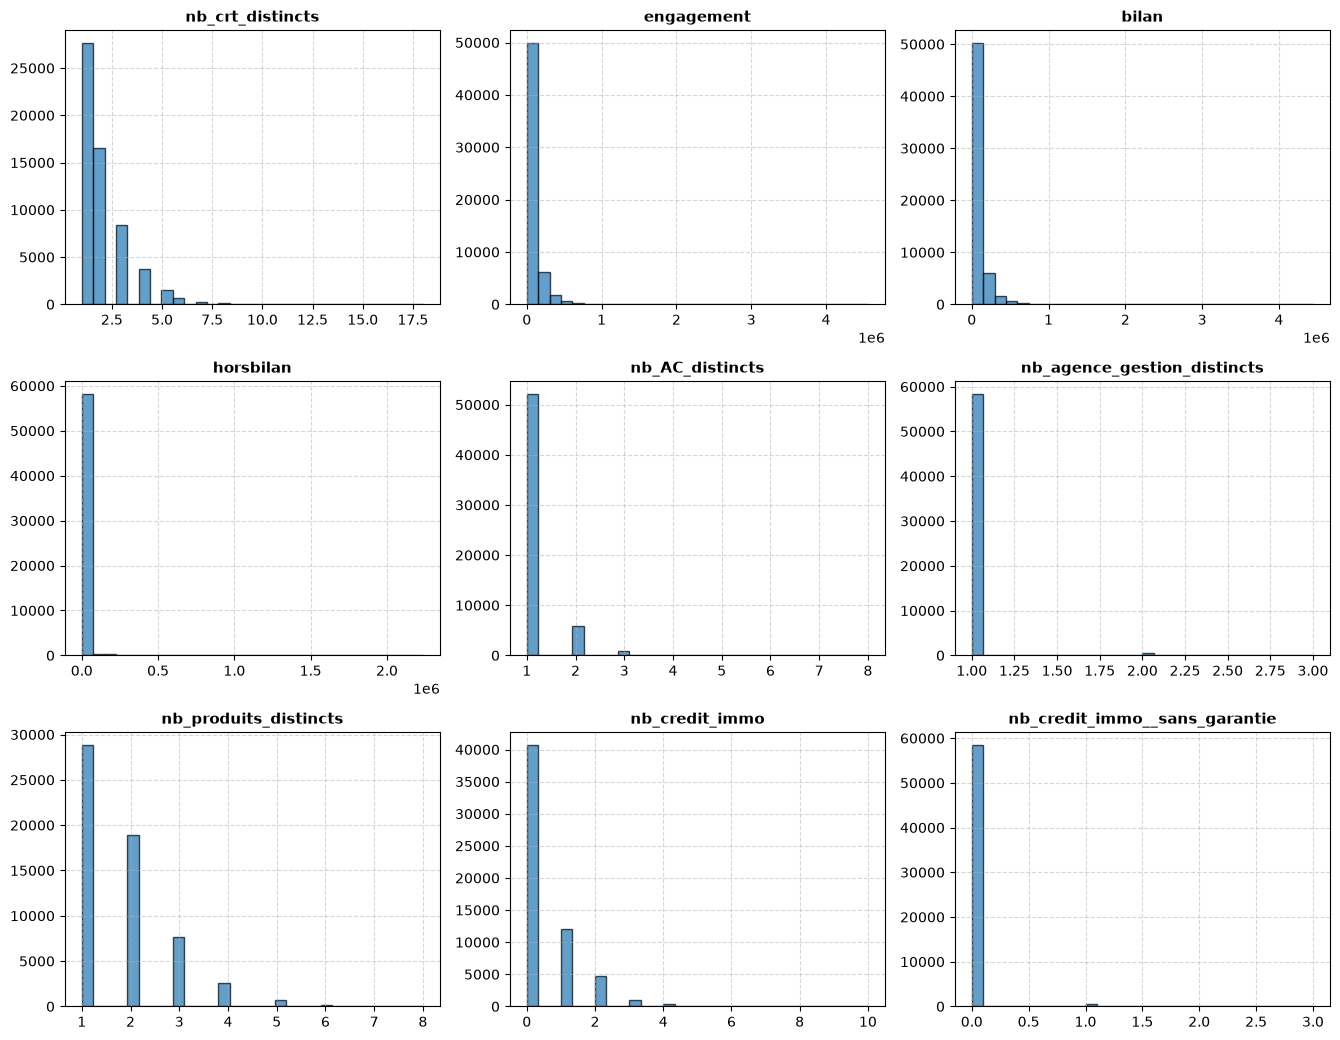

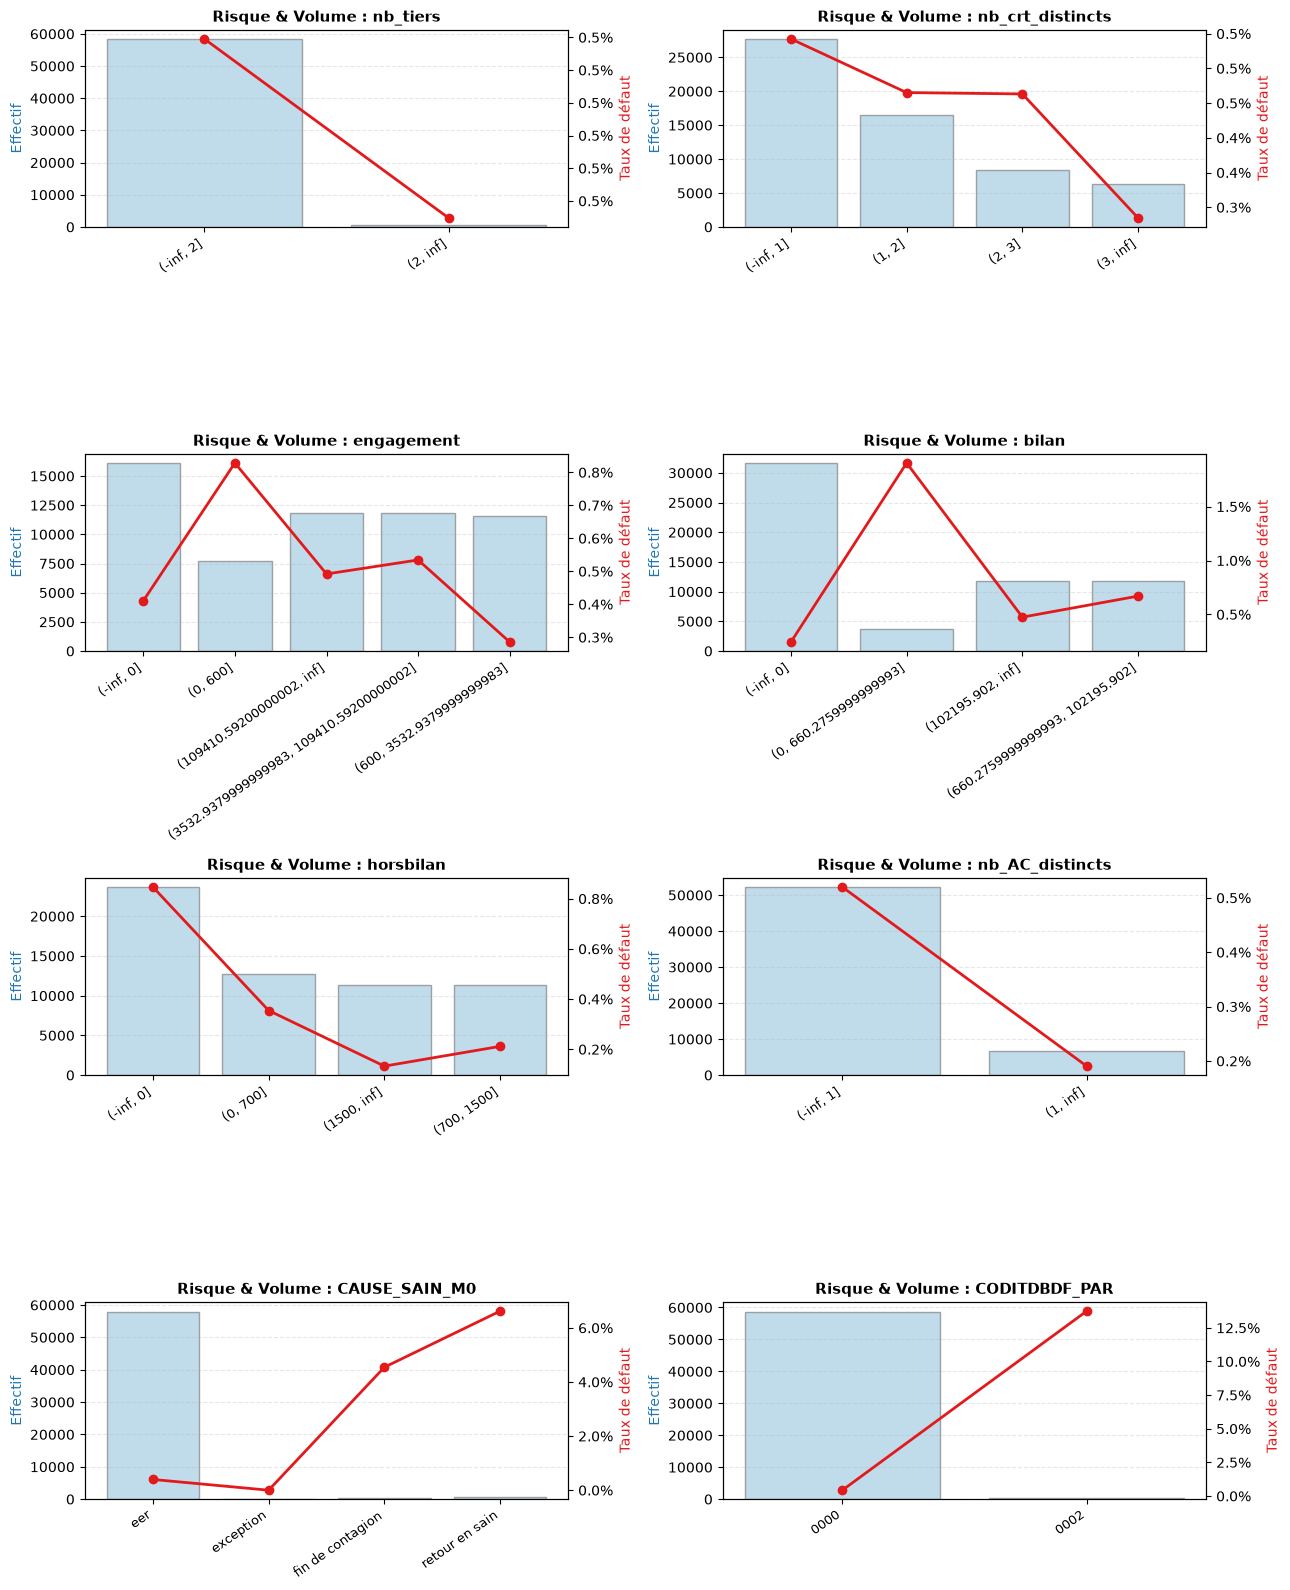

In [4]:
# 1. Histogrammes des variables quantitatives
tracer_distributions_numeriques(df_seg, VARS_NUM[1:10])  # 12 premières pour illustration

# 2. Taux de défaut et effectifs par modalité
tracer_taux_defaut_par_variable(df_seg, VARS_NUM[:6] + VARS_QUALI[:2], target=TARGET)

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


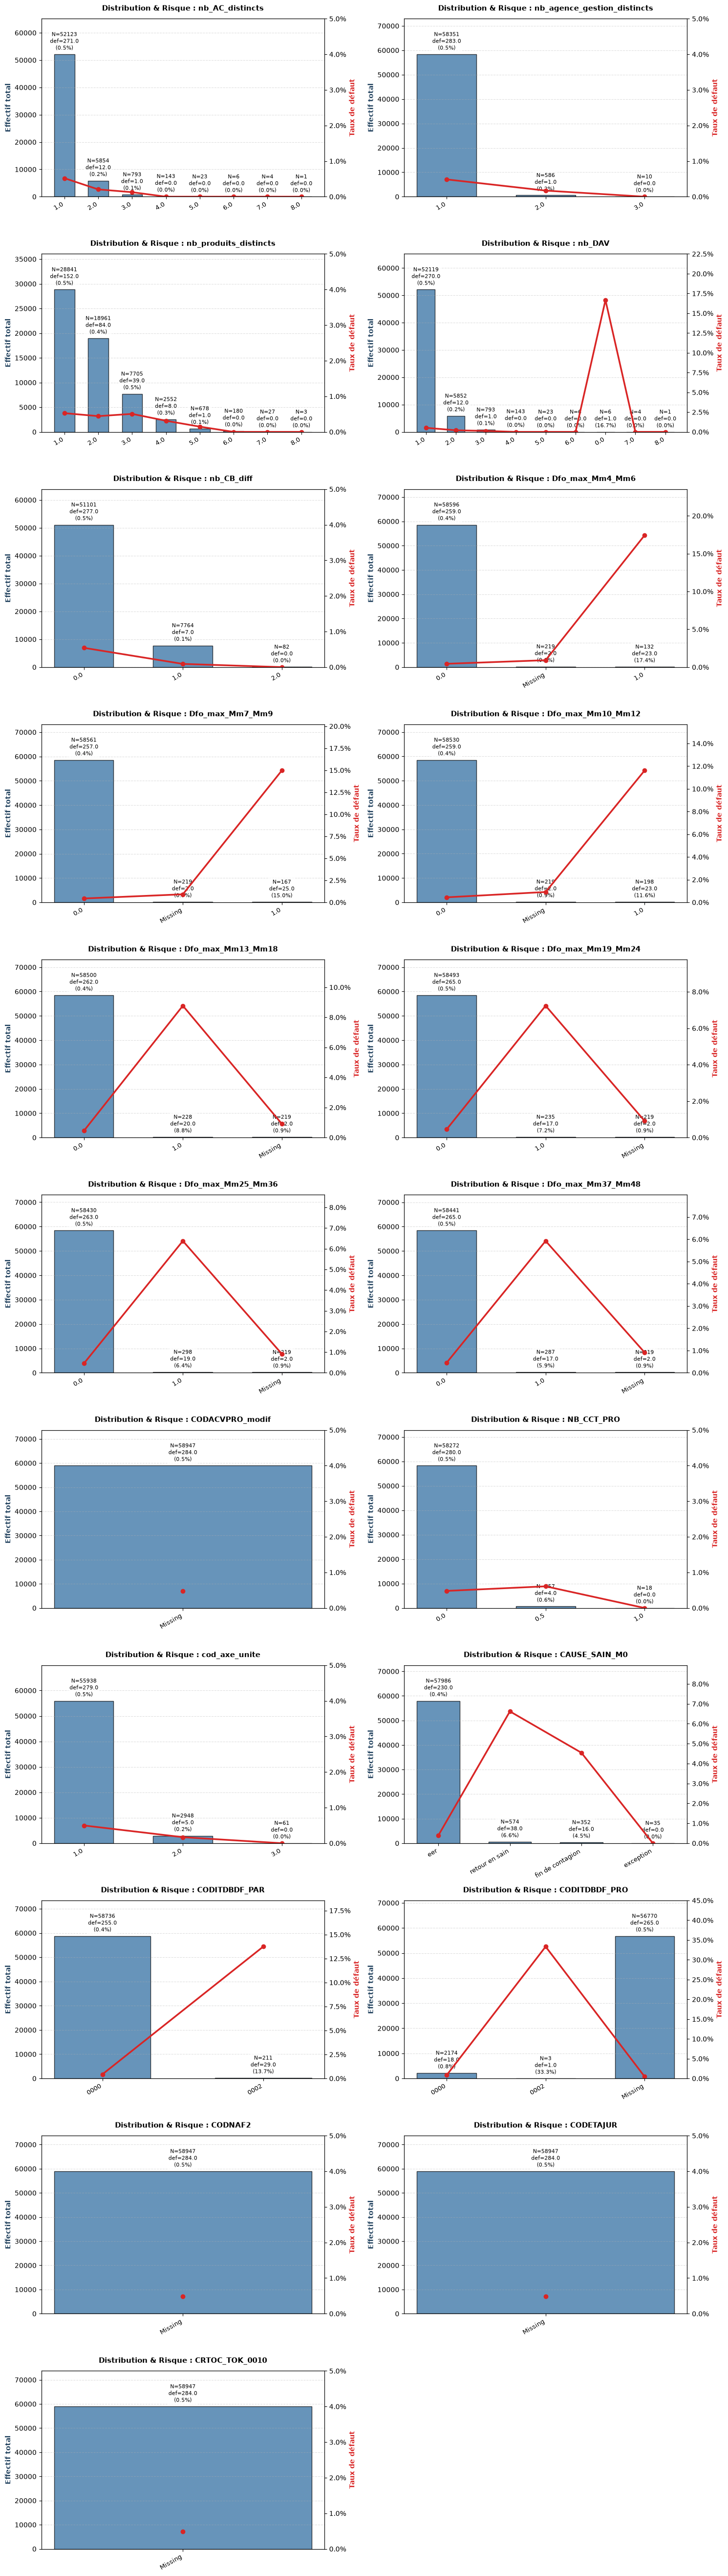

In [5]:
# Sélection automatique ou manuelle des variables discrètes (ex: moins de 15 modalités uniques)
VARS_DISCRETES = [c for c in VARS_NUM if df_seg[c].n_unique() <= 15] + VARS_QUALI

# Affichage des graphiques avec effectif, nombre de défauts et taux de défaut
tracer_analyse_discrete_avec_defauts(
    df_seg, 
    vars_discretes=VARS_DISCRETES, 
    target=TARGET,
    vars_exclues=["AGE_PM_EN_MOIS","MNT_HA102", "TOTAL_LITIGES_PRO_IND_0209", "TOTAL_TITRES_PRO_IND_0205", "CRTOP_AG_IND_0038","nb_credit_perso", "nb_credit_flex", "nb_credit_LCP", "nb_credit_revolving", "nb_credit_tresorerie", "Dfo_max_Mm1_Mm3","LISTE_CODNAF2", "LISTE_CODETAJUR", "LISTE_CODACVPRO_modif", "RATIO_LITIGES_vs_CA", "TOTAL_EPS_PRO_IND_0208","NBJ_ARR_SS", "ARR_GDT", "nb_PGE", "nb_Neiertz", "nb_credit_garantie_emise", "nb_credit_autre", "nb_credit_bail","engagement", "nb_tier", "bilan", "hors_bilan", "nb_credit_immo","nb_credit_immo__sans_garantie", "nb_credit_immo__crelog","nb_credit_immo__hypotheque", "nb_credit_MLT", "nb_credit_MLT__sans_garantie"]
)